In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Task 2.1: Load and Visualize the Data

In [2]:
df=pd.read_csv("G:\My Drive\ML\ex1data1.txt",header=None)
df.columns=["Population","Profit"]
df.head()

,Population,Profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


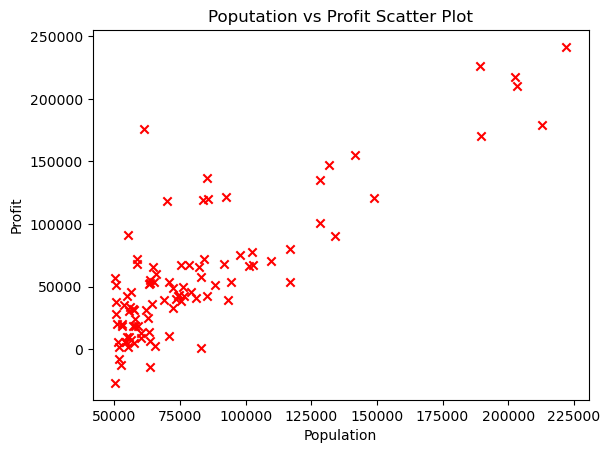

In [56]:
plt.scatter(df["Population"]*10000,df["Profit"]*10000,marker="x",c="red")
plt.xlabel("Population")
plt.ylabel("Profit")
plt.title("Poputation vs Profit Scatter Plot")
plt.show()

In [4]:
df.head()

,Population,Profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


Task 2.2: Define the Linear Regression Model

In [5]:
## Creating the input and output data
m=len(df)

X=np.c_[np.ones(m),df["Population"].values]
Y=df["Profit"].values.reshape(m,1)

In [6]:
X

array([[ 1.    ,  6.1101],
       [ 1.    ,  5.5277],
       [ 1.    ,  8.5186],
       [ 1.    ,  7.0032],
       [ 1.    ,  5.8598],
       [ 1.    ,  8.3829],
       [ 1.    ,  7.4764],
       [ 1.    ,  8.5781],
       [ 1.    ,  6.4862],
       [ 1.    ,  5.0546],
       [ 1.    ,  5.7107],
       [ 1.    , 14.164 ],
       [ 1.    ,  5.734 ],
       [ 1.    ,  8.4084],
       [ 1.    ,  5.6407],
       [ 1.    ,  5.3794],
       [ 1.    ,  6.3654],
       [ 1.    ,  5.1301],
       [ 1.    ,  6.4296],
       [ 1.    ,  7.0708],
       [ 1.    ,  6.1891],
       [ 1.    , 20.27  ],
       [ 1.    ,  5.4901],
       [ 1.    ,  6.3261],
       [ 1.    ,  5.5649],
       [ 1.    , 18.945 ],
       [ 1.    , 12.828 ],
       [ 1.    , 10.957 ],
       [ 1.    , 13.176 ],
       [ 1.    , 22.203 ],
       [ 1.    ,  5.2524],
       [ 1.    ,  6.5894],
       [ 1.    ,  9.2482],
       [ 1.    ,  5.8918],
       [ 1.    ,  8.2111],
       [ 1.    ,  7.9334],
       [ 1.    ,  8.0959],
 

In [7]:
Y


array([[17.592  ],
       [ 9.1302 ],
       [13.662  ],
       [11.854  ],
       [ 6.8233 ],
       [11.886  ],
       [ 4.3483 ],
       [12.     ],
       [ 6.5987 ],
       [ 3.8166 ],
       [ 3.2522 ],
       [15.505  ],
       [ 3.1551 ],
       [ 7.2258 ],
       [ 0.71618],
       [ 3.5129 ],
       [ 5.3048 ],
       [ 0.56077],
       [ 3.6518 ],
       [ 5.3893 ],
       [ 3.1386 ],
       [21.767  ],
       [ 4.263  ],
       [ 5.1875 ],
       [ 3.0825 ],
       [22.638  ],
       [13.501  ],
       [ 7.0467 ],
       [14.692  ],
       [24.147  ],
       [-1.22   ],
       [ 5.9966 ],
       [12.134  ],
       [ 1.8495 ],
       [ 6.5426 ],
       [ 4.5623 ],
       [ 4.1164 ],
       [ 3.3928 ],
       [10.117  ],
       [ 5.4974 ],
       [ 0.55657],
       [ 3.9115 ],
       [ 5.3854 ],
       [ 2.4406 ],
       [ 6.7318 ],
       [ 1.0463 ],
       [ 5.1337 ],
       [ 1.844  ],
       [ 8.0043 ],
       [ 1.0179 ],
       [ 6.7504 ],
       [ 1.8396 ],
       [ 4.2

In [8]:
##initializing theta_0 and theta_1 to 0
theta=np.zeros((2,1))
print(theta)

[[0.]
 [0.]]


Task 2.3: Implement the Cost Function

In [12]:
def compute_cost(X,Y,theta):
    m=len(Y)
    prediction=X @ theta  #h0x
    error=prediction-Y    # h0x-Y
    cost=(1/(2*m))*np.sum(error**2)
    return cost


In [13]:
print(compute_cost(X,Y,theta))

32.072733877455676


Task 2.4: Implement Gradient Descent

In [14]:
#pre-defining alpha and no of iteration
alpha=0.01
iterations=1500

In [ ]:
def gradient_descent(X,Y,alpha,theta,iterations):
    m=len(Y)
    cost_history=[]

    for _ in range(iterations):
        predictions=X @ theta   # X=(m*2) theta =(2*1) result=m*1
        errors=predictions-Y  #h0x-y
        '''
        errors is (m*1)matrix
        X is (m*2) matrix
        We need to find theta_0 and theta_1 in each iterations
        which is (2*1) matrix
        Therefore gradient (h0x-y)*x is
        X.T multiplied with errors
        '''
        gradient=(1/m)*(X.T @ errors)
        theta=theta-alpha*gradient
        cost_history.append(compute_cost(X,Y,theta))

    return theta,cost_history 

In [19]:
theta,cost_history=gradient_descent(X,Y,alpha,theta,iterations)

print("Theta found by gradient descent:")
print(theta)

Theta found by gradient descent:
[[-3.63029144]
 [ 1.16636235]]


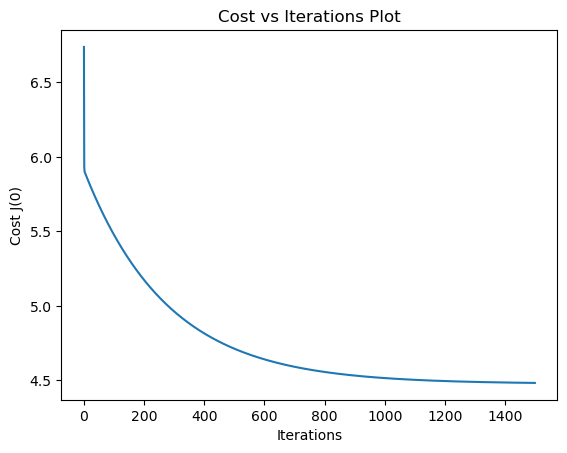

In [21]:
## cost vs iterations
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost J(0)")
plt.title("Cost vs Iterations Plot")
plt.show()

Task 2.5: Plot the Regression Line

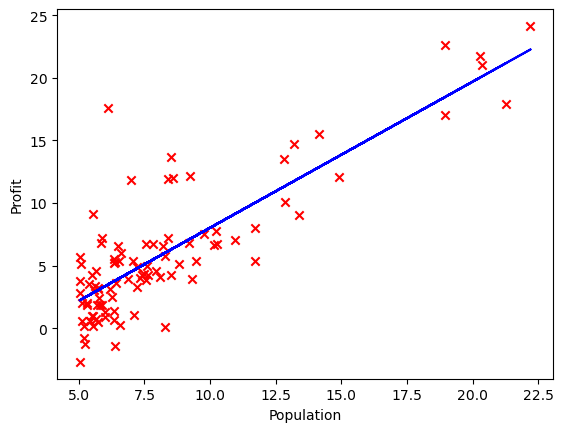

In [23]:
plt.scatter(df["Population"],df["Profit"],marker="x",c="red")
plt.plot(df["Population"],X @ theta,c="blue")
plt.xlabel("Population")
plt.ylabel("Profit")
plt.show()

In [24]:
predict1=[1,3.5]@theta
predict2=[1,7]@ theta

In [25]:
print(predict1,predict2)

[0.45197679] [4.53424501]


Task 2.6: Visualizing J(0)

In [70]:
theta0_values=np.linspace(-10,10,100)
theta1_values=np.linspace(-10,10,100)


In [71]:
J_vals=np.zeros((len(theta0_values),len(theta1_values)))

In [72]:
J_vals

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [73]:
for i in range(len(theta0_values)):
    for j in range(len(theta1_values)):
        t=np.array([[theta0_values[i]],[theta1_values[j]]])
        J_vals[i,j]=compute_cost(X,Y,t)

In [74]:
J_vals.shape

(100, 100)

In [75]:
J_vals=J_vals.T

'''
x-axis=theta0
y-axis=theta1
'''

'\nx-axis=theta0\ny-axis=theta1\n'

In [76]:
df.describe()

,Population,Profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


Surface Plot

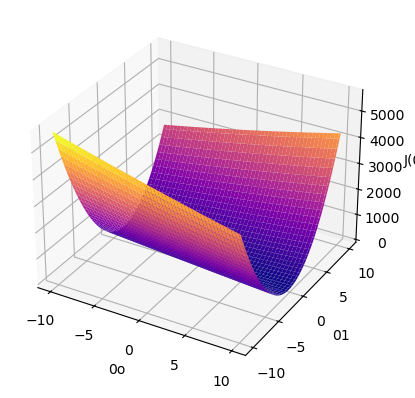

In [77]:
from mpl_toolkits.mplot3d import Axes3D

T0,T1=np.meshgrid(theta0_values,theta1_values)

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(T0,T1,J_vals,cmap="plasma")

ax.set_xlabel("0o")
ax.set_ylabel("01")
ax.set_zlabel("J(0)")
plt.show()

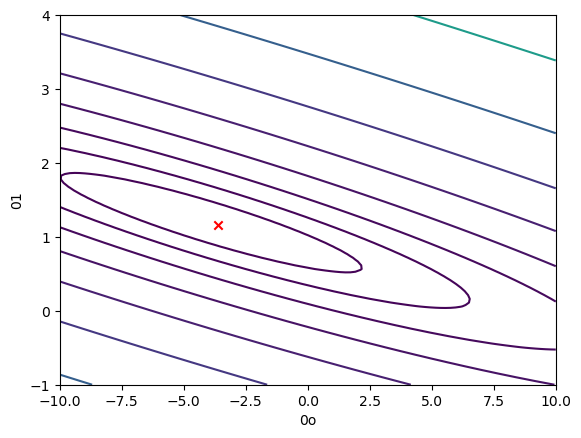

In [52]:
plt.contour(T0,T1,J_vals,levels=np.logspace(-2,3,20))
plt.xlabel("0o")
plt.ylabel("01")
plt.scatter(theta[0],theta[1],marker='x',c='red')
plt.show()